In [3]:
# Install tqdm if not installed
!pip install tqdm



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ==========================================
# MODEL TRAINING
# ==========================================

# Import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [5]:
# ================================
# Recreate Datasets and Loaders
# ================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms (same as preprocessing notebook)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Dataset paths
TRAIN_DIR = "../data/processed/train"
VAL_DIR = "../data/processed/val"
TEST_DIR = "../data/processed/test"

# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Loaders recreated successfully.")


Loaders recreated successfully.


In [6]:
# ================================
# Get Number of Classes
# ================================

# Since we used ImageFolder earlier,
# train_loader.dataset contains class info

num_classes = len(train_loader.dataset.classes)
class_names = train_loader.dataset.classes

print("Number of classes:", num_classes)
print("Sample class names:", class_names[:5])


Number of classes: 38
Sample class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [8]:
# ================================
# Define MLP Model
# ================================

class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()
        
        # Flatten image (3x224x224 → 150528)
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        self.model = nn.Sequential(
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.model(x)
        return x

# Create MLP model
mlp_model = MLP(num_classes).to(device)

print("MLP Model created successfully.")


MLP Model created successfully.


In [9]:
# ================================
# Define Loss Function and Optimizer
# ================================

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer (good default choice)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

print("Loss function and optimizer defined successfully.")


Loss function and optimizer defined successfully.


In [10]:
# =========================================
# Training Function (One Epoch)
# =========================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        
        # Move data to device (CPU/GPU)
        images = images.to(device)
        labels = labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


In [11]:
# =========================================
# Validation Function (One Epoch)
# =========================================

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        
        for images, labels in tqdm(dataloader):
            
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


In [9]:
# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


In [10]:
# =========================================
# Training Loop
# =========================================

num_epochs = 5  # You can increase later

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        mlp_model, train_loader, criterion, optimizer, device
    )

    # Validate for one epoch
    val_loss, val_acc = validate_one_epoch(
        mlp_model, val_loader, criterion, device
    )

    # Step the scheduler
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



Epoch [1/5]


100%|██████████| 255/255 [03:53<00:00,  1.09it/s]


Train Loss: 3.6518 | Train Acc: 0.0985
Val   Loss: 3.2618 | Val   Acc: 0.1214

Epoch [2/5]


100%|██████████| 255/255 [00:45<00:00,  5.65it/s]


Train Loss: 3.3501 | Train Acc: 0.0991
Val   Loss: 3.3364 | Val   Acc: 0.1017

Epoch [3/5]


...

Train Loss: 3.3549 | Train Acc: 0.1006
Val   Loss: 3.3351 | Val   Acc: 0.1021

Epoch [4/5]


100%|██████████| 255/255 [00:26<00:00,  9.64it/s]


Train Loss: 3.3472 | Train Acc: 0.1001
Val   Loss: 3.3337 | Val   Acc: 0.1049

Epoch [5/5]


100%|██████████| 255/255 [00:28<00:00,  9.07it/s]

Train Loss: 3.2932 | Train Acc: 0.1115
Val   Loss: 3.1829 | Val   Acc: 0.1302


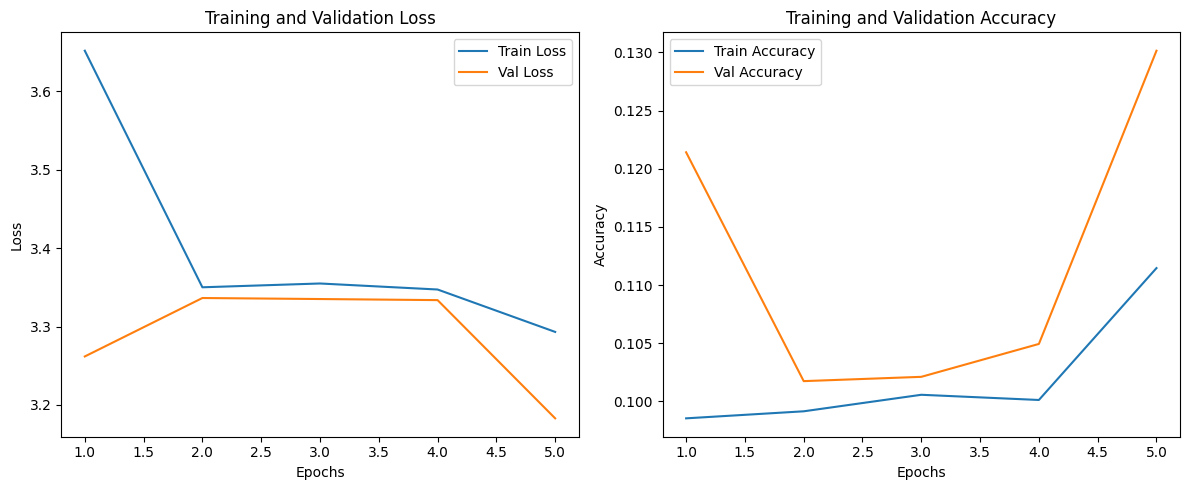

In [15]:
# =========================================
# Plot Training & Validation Curves
# =========================================

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# =========================================
# Simple CNN Model
# =========================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature Extraction Layers
        self.features = nn.Sequential(
            
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Classification Layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [14]:
# ==========================================
# Initialize CNN Model
# ==========================================

cnn_model = SimpleCNN(num_classes=num_classes).to(device)

print("CNN model initialized successfully.")



# ==========================================
# Loss Function and Optimizer (WITH CLASS WEIGHTS)
# ==========================================

cnn_criterion = torch.nn.CrossEntropyLoss()


cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

print("Loss function and optimizer defined for CNN.")


CNN model initialized successfully.
Loss function and optimizer defined for CNN.


In [15]:

# ==========================================
# CNN Training Loop
# ==========================================

num_epochs = 4   # Increased epochs

cnn_train_losses = []
cnn_val_losses = []
cnn_train_accuracies = []
cnn_val_accuracies = []

for epoch in range(num_epochs):

    print(f"\nCNN Epoch [{epoch+1}/{num_epochs}]")

    # Train one epoch
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, device
    )

    # Validate one epoch
    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, cnn_criterion, device
    )

    # Store metrics
    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_train_accuracies.append(train_acc)
    cnn_val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



CNN Epoch [1/4]


100%|██████████| 255/255 [05:35<00:00,  1.32s/it]


Train Loss: 3.2675 | Train Acc: 0.2184
Val   Loss: 2.5202 | Val   Acc: 0.2859

CNN Epoch [2/4]


100%|██████████| 255/255 [05:26<00:00,  1.28s/it]


Train Loss: 2.6924 | Train Acc: 0.2518
Val   Loss: 2.1385 | Val   Acc: 0.3559

CNN Epoch [3/4]


100%|██████████| 255/255 [02:19<00:00,  1.83it/s]


Train Loss: 2.5227 | Train Acc: 0.2849
Val   Loss: 2.0632 | Val   Acc: 0.4265

CNN Epoch [4/4]


100%|██████████| 255/255 [02:01<00:00,  2.10it/s]

Train Loss: 2.3586 | Train Acc: 0.3229
Val   Loss: 1.7184 | Val   Acc: 0.5303


In [16]:
torch.save(cnn_model.state_dict(), "cnn_epoch4.pth")


In [19]:
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'optimizer_state_dict': cnn_optimizer.state_dict(),
    'epoch': 4
}, "cnn_checkpoint.pth")


In [20]:
additional_epochs = 3

for epoch in range(additional_epochs):
    
    print(f"\nContinuation Epoch [{epoch+1}/{additional_epochs}]")

    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, cnn_criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



Continuation Epoch [1/3]


100%|██████████| 255/255 [05:39<00:00,  1.33s/it]


Train Loss: 2.1137 | Train Acc: 0.3786
Val   Loss: 1.4068 | Val   Acc: 0.5800

Continuation Epoch [2/3]


100%|██████████| 255/255 [03:11<00:00,  1.34it/s]


Train Loss: 1.9491 | Train Acc: 0.4207
Val   Loss: 1.3838 | Val   Acc: 0.5927

Continuation Epoch [3/3]


100%|██████████| 255/255 [02:18<00:00,  1.84it/s]

Train Loss: 1.7521 | Train Acc: 0.4703
Val   Loss: 1.1446 | Val   Acc: 0.6622


In [21]:
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'optimizer_state_dict': cnn_optimizer.state_dict(),
    'epoch': 7
}, "cnn_checkpoint_epoch7.pth")


In [23]:
additional_epochs = 4

for epoch in range(7, 7 + additional_epochs):
    
    print(f"\nContinuation Epoch [{epoch+1}/11]")

    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        cnn_model, val_loader, cnn_criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



Continuation Epoch [8/11]


 10%|▉         | 116/1188 [05:04<46:53,  2.62s/it]


KeyboardInterrupt: 

In [19]:
import torch

# Save MLP model
torch.save(mlp_model.state_dict(), "mlp_model.pth")
print("MLP model saved successfully!")

# Save CNN model
torch.save(cnn_model.state_dict(), "cnn_model.pth")
print("CNN model saved successfully!")


MLP model saved successfully!
CNN model saved successfully!


In [20]:
import os
print(os.listdir())


['01_dataset_audit.ipynb', '02_dataset_split.ipynb', '03_preprocessing_and_loader.ipynb', '04_model_training.ipynb', 'cnn_model.pth', 'mlp_model.pth']


In [21]:
print("cnn_train_losses exists?" , "cnn_train_losses" in globals())


cnn_train_losses exists? True


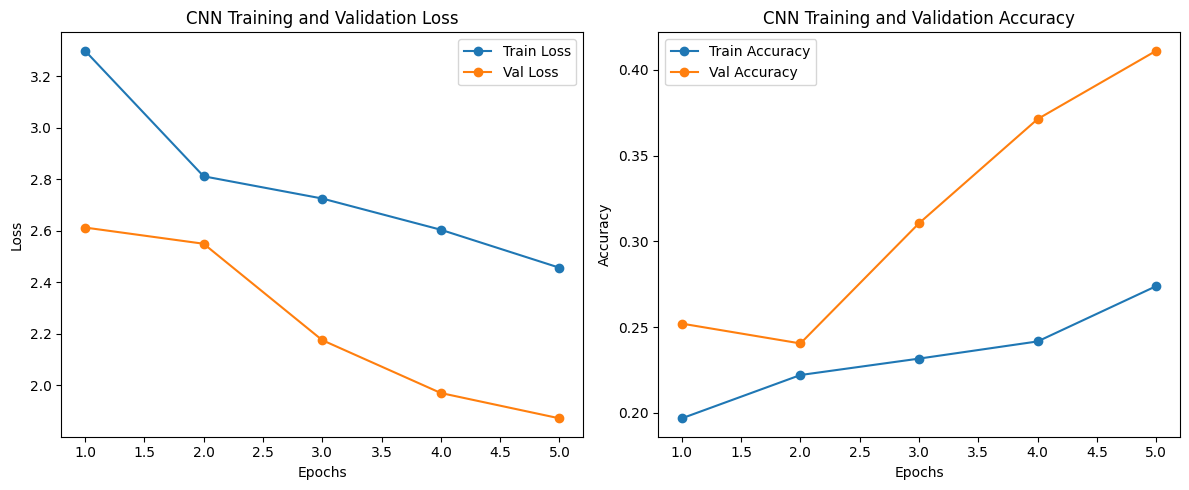

In [22]:
# =========================================
# Plot CNN Training & Validation Curves
# =========================================

import matplotlib.pyplot as plt

# Make sure epochs match training
num_epochs = 5
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# -------------------------
# 1️⃣ Loss Plot
# -------------------------
plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_train_losses, marker='o', label="Train Loss")
plt.plot(epochs, cnn_val_losses, marker='o', label="Val Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# -------------------------
# 2️⃣ Accuracy Plot
# -------------------------
plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, cnn_val_accuracies, marker='o', label="Val Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()



In [23]:
print("Final MLP Validation Accuracy :", val_accuracies[-1])
print("Final CNN Validation Accuracy :", cnn_val_accuracies[-1])


Final MLP Validation Accuracy : 0.13015131012424652
Final CNN Validation Accuracy : 0.41124369541148975


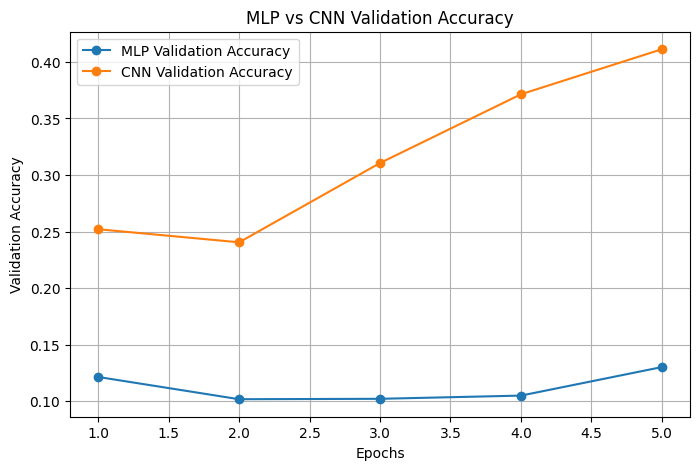

In [24]:
# ==========================================
# MLP vs CNN Validation Accuracy Comparison
# ==========================================

import matplotlib.pyplot as plt

epochs = range(1, len(val_accuracies) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, val_accuracies, marker='o', label='MLP Validation Accuracy')
plt.plot(epochs, cnn_val_accuracies, marker='o', label='CNN Validation Accuracy')

plt.title("MLP vs CNN Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


In [25]:
cnn_model.eval()


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias

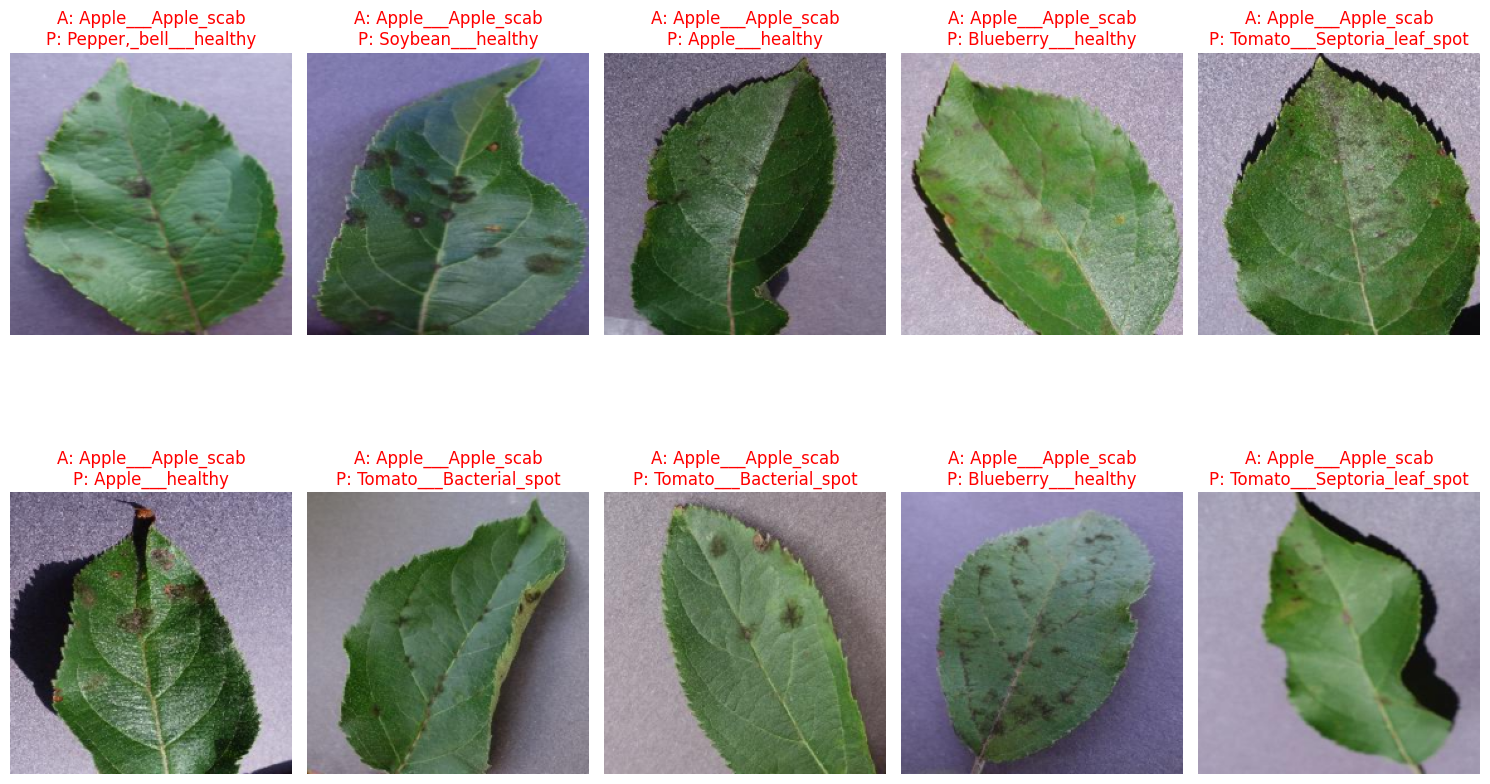

In [28]:
# ==========================================
# Visualize 10 CNN Predictions (Color-Coded)
# ==========================================

import torch
import matplotlib.pyplot as plt

cnn_model.eval()

# Get one batch from validation loader
images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = cnn_model(images)
    _, preds = torch.max(outputs, 1)

# Move back to CPU
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(15, 10))

num_samples = 10

for i in range(num_samples):
    plt.subplot(2, 5, i+1)

    img = images[i].permute(1, 2, 0)
    plt.imshow(img)

    actual = class_names[labels[i]]
    predicted = class_names[preds[i]]

    if preds[i] == labels[i]:
        color = "green"
    else:
        color = "red"

    plt.title(f"A: {actual}\nP: {predicted}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()
